# <h1 style="text-align: center;">Optimal Control of TCLab using a Gaussian process regression embedded in Pyomo</h1>

<h2 style="text-align: center;">Notebook v7</h2>

<p style="text-align: center;">Alex Dowling<sup>a</sup>, Jacob P. Krell<sup>b</sup>, David S. Mebane<sup>b</sup>

<p style="text-align: center;"><sup>a</sup>Department of Chemical and Biomolecular Engineering, University of Notre Dame, Notre Dame, IN 46556, USA <br>
<sup>b</sup>Department of Mechanical and Aerospace Engineering, West Virginia University, Morgantown, WV, 26506-6106, USA</p>

## Change Log

- adapted from *pyomo_tclab_v6_optimize1_with_v5c2.ipynb*
- previously internal ```fokl_to_pyomo``` function accessed through updated FoKL module

## Script

In [1]:
# =====================================================================
# =====================================================================
# SYSTEM-LEVEL PARAMETERS:

Simulate = False  # boolean to use dae.Simulator; uses IPOPT if false

In [2]:
# =====================================================================
# =====================================================================
# MODULES:

from FoKL import FoKLRoutines
import os
dir = os.path.abspath('')  # directory of notebook
# -----------------------------------------------------------------------
# UNCOMMENT IF USING LOCAL FOKL PACKAGE:
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
# -----------------------------------------------------------------------
import pandas as pd
from scipy.interpolate import interp1d
import numpy as np
import pyomo.environ as pyo
import pyomo.dae as dae
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pyomo.dae import Simulator

In [3]:
# =====================================================================
# =====================================================================
# LOAD AND PARSE SINE TEST DATA:

data = pd.read_csv(os.path.join(dir, "data", "tclab_sine_test.csv"))

tvec = data["Time"].values
Q1 = data["Q1"].values
TS1 = data["T1"].values

Q1f = interp1d(tvec, Q1, kind='previous')  # piecewise Q1
dQ1f_analytic = lambda t: 1500 * np.cos(30 * np.pi * t / tvec[-1]) * np.pi / tvec[-1]  # derivative of analytic Q1
dQ1f = interp1d(tvec, dQ1f_analytic(tvec), kind='previous')  # piecewise derivative of analytic Q1

In [4]:
# =====================================================================
# =====================================================================
# SMOOTHING OF SINE TEST:

window = 9  # odd number, mean at center +/- floor(window/2))

def smooth(TS1, window):
    """Apply centered average of size window."""
    TS1_smooth = np.zeros_like(TS1)
    w2 = int(np.floor(window / 2))
    w2p1 = w2 + 1

    # bleed in:
    for i in range(w2):
        TS1_smooth[i] = np.mean(TS1[:(i + w2p1)])

    # center:
    for i in range(w2, TS1_smooth.size - w2):
        TS1_smooth[i] = np.mean(TS1[(i - w2):(i + w2p1)])

    # bleed out:
    for i in range(-w2, 0):
        TS1_smooth[i] = np.mean(TS1[(i - w2)::])

    return TS1_smooth

TS1_smooth = smooth(TS1, window)

In [5]:
# =====================================================================
# =====================================================================
# DERIVATIVE OF SMOOTHED SINE TEST:

def gradient_h4(x, h):
    """h is step size. Order of error is h^4."""
    dx = np.zeros_like(x)

    # bleed in:
    h2 = 2 * h
    dx[0] = (x[1] - x[0]) / h
    dx[1] = (x[2] - x[0]) / h2

    # center difference:
    h12 = 12 * h
    for i in range(2, x.shape[0] - 2):
        dx[i] = (x[i - 2] - 8 * x[i - 1] + 8 * x[i + 1] - x[i + 2]) / h12
    
    # bleed out:
    dx[-2] = (x[-1] - x[-3]) / h2
    dx[-1] = (x[-1] - x[-2]) / h

    return dx

dTS1 = gradient_h4(TS1_smooth, tvec[1] - tvec[0])
dTS1f = interp1d(tvec, dTS1, kind='previous')  # piecewise, grab previous value

In [6]:
# =====================================================================
# =====================================================================
# GP MODEL OF DIFFERENTIATED SINE TEST:

try:
    GP_dT = FoKLRoutines.load(os.path.join("models", "pyomo_tclab_v7.fokl"))
except Exception as exception:
    GP_dT = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True)
    GP_dT.fit([TS1_smooth, Q1, dQ1f(tvec)], dTS1, clean=True)
    GP_dT.save(os.path.join("models", "pyomo_tclab_v7.fokl"))

In [7]:
# =====================================================================
# =====================================================================
# CONTROLLER REFERENCE TRAJECTORY:

# time grid
t0 = 0
tf = 999
dt = 1
n = round(tf / dt)
t_grid = np.linspace(t0, tf, n + 1)

# ambient temperature
Tamb = 21.0

# time points of setpoint/reference values
tr = [t0, 50, 150, 450, 550, tf]

# setpoint/reference
def r(t):
    return np.interp(t, tr, [Tamb, Tamb, 60, 60, 35, 35])

# derivative of setpoint/reference
dr_interp = interp1d(tr, [0, (60 - Tamb) / 100, 0, (35 - 60) / 100, 0, 0], kind='previous')
def dr(t):
    return float(dr_interp(t))

In [8]:
# =====================================================================
# =====================================================================
# OPTIMIZATION USING GP MODEL - CREATION OF PYOMO MODEL:

# Create a Pyomo model
m = pyo.ConcreteModel('TCLab Heater with GP Model')

# Define time domain
m.t = dae.ContinuousSet(bounds=(t0, tf))

# Define the state variables as a function of time
m.Ts1 = pyo.Var(m.t)

# Define the control variable (heater power) as a function of time
m.u1 = pyo.Var(m.t, bounds=(0, 100), initialize=50.0)  # != Q1f(t0)

# Define the derivative of the control variable
m.du1 = dae.DerivativeVar(m.u1, wrt=m.t)  # != dQ1f(t0)

# Define the derivatives of the state variables
m.dTs1 = dae.DerivativeVar(m.Ts1, wrt=m.t)

# Fix the initial conditions
m.Ts1[t0].fix(Tamb)

# Arguments to embed GP in Pyomo model:
xvars = [m.Ts1, m.u1, m.du1]
yvar = m.dTs1
draws = 5

# Embed GP:
GP_dT.to_pyomo(xvars, yvar, m, draws, with_blocks=False)

In [9]:
# =====================================================================
# =====================================================================
# OPTIMIZATION USING GP MODEL - SOLVER:

In [10]:
# =====================================================================
# SOLVE WITH SIMULATOR:

if Simulate is True:

    # To enable dae.Simulator to run, the DerivativeVar's need to exist as the LHS of a Constraint.
    # m.dTs1 already satisifies this, with the m.y_avg Expression from FoKL as the RHS.
    # Creating a dummy so that m.du1 may also satisfy this:
    m.du1_dummy = pyo.Var(m.t)

    @m.Constraint(m.t)
    def constr_dudt(m, t):
        return m.du1[t] == m.du1_dummy[t]

    # Then, the RHS's need to be initialized:
    m.var_input = pyo.Suffix(direction=pyo.Suffix.LOCAL)
    m.var_input[m.du1_dummy] = {t0: 0}  # == m.du1
    m.var_input[m.y_avg] = {}  # == m.dTs1, defined to match the control reference trajectory
    for t in tr:
        m.var_input[m.y_avg].update({t: dr(t)})

    # Simulate:
    sim = Simulator(m, package='casadi')
    tsim, profiles = sim.simulate(
        numpoints=100, integrator='idas', varying_inputs=m.var_input
    )

    # Plot:
    plt.plot(tsim, profiles)
    plt.title('Simulation Results, dTs1 = d(r)/dt, du1[t0] = 0')
    plt.xlabel('Time (s)')
    plt.legend(['Ts1 (°C)', 'u1 (%)'])
    plt.grid()
    plt.show()

Ipopt 3.14.16: linear_solver=ma27

Exception of type: DYNAMIC_LIBRARY_FAILURE in file "Common/IpLibraryLoader.cpp" at line 86:
 Exception message: libhsl.so: cannot open shared object file: No such file or directory

EXIT: Library loading failure.
model.name="TCLab Heater with GP Model";
    - termination condition: other
    - message from solver: <undefined>


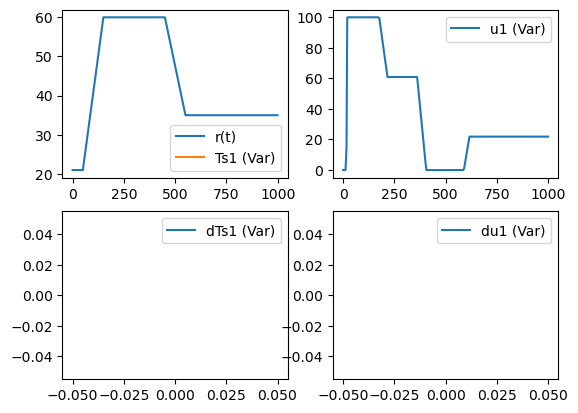

In [11]:
# =====================================================================
# SOLVE WITH IPOPT:

if Simulate is False:

    # Define the integral of the squared error
    @m.Integral(m.t)
    def ise(m, t):
        return (r(t) - m.Ts1[t]) ** 2

    # Define the objective function
    @m.Objective(sense=pyo.minimize)
    def objective(m):
        return m.ise

    # Apply a collocation method to numerically integrate the differential equations
    pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=100, wrt=m.t)

    # Fix u1 to benchmark solution, forcing 0 DoF for sake of debugging:

    u1_benchmark = np.loadtxt(os.path.join(dir, 'data', 'u1_benchmark_solution.csv'), delimiter=',')
    u1_benchmark = np.concatenate([np.array([t0, 0])[np.newaxis, :],
                                   u1_benchmark[1:107, :],
                                   u1_benchmark[130:218, :],
                                   u1_benchmark[243:354, :],
                                   u1_benchmark[370::, :]], axis=0)  # remove oscillations

    def u_ref(t):
        """u1 values from benchmark solution."""
        u1 = np.interp(t, u1_benchmark[:, 0], u1_benchmark[:, 1])
        if u1 < 0:
            return 0
        elif u1 > 100:
            return 100
        else:
            return u1

    for t in m.t:
        # m.y_avg[t] = dr(t)  # forces Ts1 to match r(t), but u1 is unaffected
        # m.dTs1[t].fix(dr(t))  # Ts1 gets shape but has large "stepwise" jumps in value
        # m.u1[t].fix(u_ref(t))  # Ts1 not accurate
        m.u1[t] = u_ref(t)  # initialized but not fixed; same solution as without this initialization

    # Call our nonlinear optimization/equation solver, Ipopt
    solver = pyo.SolverFactory('ipopt')
    solver.options['linear_solver'] = 'ma27'
    solver.solve(m, tee=True)

    # Plot solution

    tvec = m.t.data()

    fig, axs = plt.subplots(2, 2)

    axs[0, 0].plot()
    axs[0, 0].plot(tvec, r(tvec))
    axs[0, 0].plot(tvec, m.Ts1[:]())
    axs[0, 0].legend(['r(t)', 'Ts1 (Var)'])

    axs[0, 1].plot(tvec, m.u1[:]())
    axs[0, 1].legend(['u1 (Var)'])

    axs[1, 1].plot(tvec, m.du1[:]())
    axs[1, 1].legend(['du1 (Var)'])

    axs[1, 0].plot(tvec, m.dTs1[:]())
    axs[1, 0].legend(['dTs1 (Var)'])

    plt.show()